# Practical Hadoop Architecture Demo with Python

## HDFS + NameNode + DataNode + Replication + MapReduce

This notebook gives a practical feel of Hadoop architecture without installing Hadoop.

We will simulate:
- A large file being split into HDFS blocks
- Blocks being stored on DataNodes
- The NameNode storing metadata
- Replication factor for fault tolerance
- DataNode failure and recovery
- Reading a file from HDFS blocks
- MapReduce using Map → Shuffle → Reduce

## Why a Simulation?

Installing Hadoop locally or inside Colab is heavy for a beginner class.

Instead, this notebook builds a simple Python-based model of Hadoop concepts.

The goal is not to replace Hadoop, but to understand how Hadoop works internally.


# 1. Hadoop Architecture Overview

Hadoop has two major parts:

```text
HDFS       → Distributed file storage
MapReduce  → Distributed batch processing
```

## HDFS Architecture

```text
Client
  |
  | asks metadata
  v
NameNode
  |
  | returns block locations
  v
DataNodes store actual file blocks
```

## Main Components

| Component | Role |
|---|---|
| NameNode | Stores metadata about files and blocks |
| DataNode | Stores actual data blocks |
| Block | A chunk of a large file |
| Replication Factor | Number of copies of each block |
| Client | Reads/writes files using NameNode and DataNodes |


# 2. Class Scenario

You are a Data Engineer at an e-commerce company.

You receive a large orders file:

```text
orders_analytics.csv
```

The file contains order events from many cities.

Instead of storing the whole file on one machine, Hadoop HDFS splits it into blocks and stores those blocks across multiple DataNodes.

Then MapReduce calculates:

```text
Total completed order revenue by city
```


# 3. Create Sample Order Data

We will create a sample dataset to act like a large file.

In a real Hadoop system, this file may be many GBs or TBs.


In [ ]:
import pandas as pd
import random
import math
from collections import defaultdict

random.seed(42)

cities = ["Delhi", "Mumbai", "Bangalore", "Pune", "Chennai", "Hyderabad"]
statuses = ["completed", "pending", "cancelled", "failed"]

orders = []

for order_id in range(1001, 1101):
    orders.append({
        "order_id": order_id,
        "customer_id": random.randint(501, 530),
        "city": random.choice(cities),
        "amount": random.randint(100, 5000),
        "status": random.choices(statuses, weights=[0.6, 0.2, 0.1, 0.1])[0]
    })

orders_df = pd.DataFrame(orders)
orders_df.head()


,order_id,customer_id,city,amount,status
0,1001,521,Delhi,304,pending
1,1002,508,Mumbai,1243,pending
2,1003,522,Hyderabad,4567,completed
3,1004,514,Delhi,344,completed
4,1005,508,Chennai,317,completed


In [ ]:
orders_df.to_csv("orders_analytics.csv", index=False)

with open("orders_analytics.csv", "r") as f:
    file_content = f.read()

print(file_content[:500])
print("\nFile size in characters:", len(file_content))


order_id,customer_id,city,amount,status
1001,521,Delhi,304,pending
1002,508,Mumbai,1243,pending
1003,522,Hyderabad,4567,completed
1004,514,Delhi,344,completed
1005,508,Chennai,317,completed
1006,523,Hyderabad,4564,completed
1007,515,Chennai,2378,cancelled
1008,501,Mumbai,3562,completed
1009,505,Mumbai,2857,completed
1010,513,Delhi,3040,cancelled
1011,520,Bangalore,455,pending
1012,518,Delhi,3200,completed
1013,510,Hyderabad,3062,completed
1014,523,Delhi,475,pending
1015,525,Bangalore,753,cancell

File size in characters: 3118


# 4. Simulating HDFS Blocks

In real HDFS, block size is often large, such as 128 MB.

For classroom demonstration, we will use a much smaller block size:

```text
Block size = 400 characters
```

This lets us see multiple blocks in a small example.


In [ ]:
BLOCK_SIZE = 400

def split_file_into_blocks(content, block_size):
    blocks = []
    for i in range(0, len(content), block_size):
        block_content = content[i:i + block_size]
        blocks.append({
            "block_id": f"block_{len(blocks) + 1}",
            "content": block_content,
            "size": len(block_content)
        })
    return blocks

blocks = split_file_into_blocks(file_content, BLOCK_SIZE)

print("Total blocks created:", len(blocks))
for block in blocks[:3]:
    print(block["block_id"], "size:", block["size"])


Total blocks created: 8
block_1 size: 400
block_2 size: 400
block_3 size: 400


## Key Hadoop Idea

A large file is not stored as one big object on one computer.

It is split into blocks:

```text
orders_analytics.csv
    ├── block_1
    ├── block_2
    ├── block_3
    └── ...
```


# 5. Simulating DataNodes

DataNodes are worker machines that store actual blocks.

Let us create 5 fake DataNodes.


In [ ]:
data_nodes = {
    "DataNode-1": {},
    "DataNode-2": {},
    "DataNode-3": {},
    "DataNode-4": {},
    "DataNode-5": {}
}

list(data_nodes.keys())


['DataNode-1', 'DataNode-2', 'DataNode-3', 'DataNode-4', 'DataNode-5']

# 6. Simulating Replication Factor

Replication factor means how many copies of each block exist.

For example:

```text
Replication factor = 3
```

This means each block is stored on 3 different DataNodes.


In [ ]:
REPLICATION_FACTOR = 3

def store_blocks_with_replication(blocks, data_nodes, replication_factor):
    namenode_metadata = {}
    node_names = list(data_nodes.keys())

    for block in blocks:
        selected_nodes = random.sample(node_names, replication_factor)

        namenode_metadata[block["block_id"]] = {
            "size": block["size"],
            "locations": selected_nodes
        }

        for node in selected_nodes:
            data_nodes[node][block["block_id"]] = block["content"]

    return namenode_metadata

namenode_metadata = store_blocks_with_replication(
    blocks,
    data_nodes,
    REPLICATION_FACTOR
)

namenode_metadata


{'block_1': {'size': 400,
  'locations': ['DataNode-4', 'DataNode-2', 'DataNode-1']},
 'block_2': {'size': 400,
  'locations': ['DataNode-3', 'DataNode-5', 'DataNode-1']},
 'block_3': {'size': 400,
  'locations': ['DataNode-3', 'DataNode-2', 'DataNode-5']},
 'block_4': {'size': 400,
  'locations': ['DataNode-2', 'DataNode-1', 'DataNode-5']},
 'block_5': {'size': 400,
  'locations': ['DataNode-5', 'DataNode-4', 'DataNode-3']},
 'block_6': {'size': 400,
  'locations': ['DataNode-2', 'DataNode-5', 'DataNode-1']},
 'block_7': {'size': 400,
  'locations': ['DataNode-2', 'DataNode-4', 'DataNode-1']},
 'block_8': {'size': 318,
  'locations': ['DataNode-2', 'DataNode-3', 'DataNode-5']}}

# 7. NameNode Metadata

The NameNode does not store the actual file data.

It stores metadata like:

```text
file name
block IDs
block sizes
which DataNodes have each block
replication factor
```

Let us create file-level metadata.


In [ ]:
hdfs_file_metadata = {
    "file_name": "orders_analytics.csv",
    "block_size": BLOCK_SIZE,
    "replication_factor": REPLICATION_FACTOR,
    "blocks": list(namenode_metadata.keys())
}

hdfs_file_metadata


{'file_name': 'orders_analytics.csv',
 'block_size': 400,
 'replication_factor': 3,
 'blocks': ['block_1',
  'block_2',
  'block_3',
  'block_4',
  'block_5',
  'block_6',
  'block_7',
  'block_8']}

## NameNode Metadata Table


In [ ]:
metadata_rows = []

for block_id, info in namenode_metadata.items():
    metadata_rows.append({
        "block_id": block_id,
        "size": info["size"],
        "stored_on": ", ".join(info["locations"])
    })

pd.DataFrame(metadata_rows)


,block_id,size,stored_on
0,block_1,400,"DataNode-4, DataNode-2, DataNode-1"
1,block_2,400,"DataNode-3, DataNode-5, DataNode-1"
2,block_3,400,"DataNode-3, DataNode-2, DataNode-5"
3,block_4,400,"DataNode-2, DataNode-1, DataNode-5"
4,block_5,400,"DataNode-5, DataNode-4, DataNode-3"
5,block_6,400,"DataNode-2, DataNode-5, DataNode-1"
6,block_7,400,"DataNode-2, DataNode-4, DataNode-1"
7,block_8,318,"DataNode-2, DataNode-3, DataNode-5"


# 8. DataNode Storage View

Let us see which blocks are stored on each DataNode.


In [ ]:
datanode_report = []

for node, stored_blocks in data_nodes.items():
    datanode_report.append({
        "data_node": node,
        "num_blocks_stored": len(stored_blocks),
        "blocks": ", ".join(stored_blocks.keys())
    })

pd.DataFrame(datanode_report)


,data_node,num_blocks_stored,blocks
0,DataNode-1,5,"block_1, block_2, block_4, block_6, block_7"
1,DataNode-2,6,"block_1, block_3, block_4, block_6, block_7, b..."
2,DataNode-3,4,"block_2, block_3, block_5, block_8"
3,DataNode-4,3,"block_1, block_5, block_7"
4,DataNode-5,6,"block_2, block_3, block_4, block_5, block_6, b..."


# 9. Reading a File from HDFS

When a client reads a file:

```text
1. Client asks NameNode for block locations.
2. NameNode returns DataNodes for each block.
3. Client reads each block from one available DataNode.
4. Client combines blocks in order.
```

Let us simulate this.


In [ ]:
def read_file_from_hdfs(file_metadata, namenode_metadata, data_nodes):
    reconstructed_content = ""

    for block_id in file_metadata["blocks"]:
        locations = namenode_metadata[block_id]["locations"]
        block_found = False

        for node in locations:
            if block_id in data_nodes[node]:
                reconstructed_content += data_nodes[node][block_id]
                block_found = True
                break

        if not block_found:
            raise Exception(f"Block {block_id} is unavailable!")

    return reconstructed_content

reconstructed_file = read_file_from_hdfs(
    hdfs_file_metadata,
    namenode_metadata,
    data_nodes
)

print("Original and reconstructed file match:", reconstructed_file == file_content)
print(reconstructed_file[:500])


Original and reconstructed file match: True
order_id,customer_id,city,amount,status
1001,521,Delhi,304,pending
1002,508,Mumbai,1243,pending
1003,522,Hyderabad,4567,completed
1004,514,Delhi,344,completed
1005,508,Chennai,317,completed
1006,523,Hyderabad,4564,completed
1007,515,Chennai,2378,cancelled
1008,501,Mumbai,3562,completed
1009,505,Mumbai,2857,completed
1010,513,Delhi,3040,cancelled
1011,520,Bangalore,455,pending
1012,518,Delhi,3200,completed
1013,510,Hyderabad,3062,completed
1014,523,Delhi,475,pending
1015,525,Bangalore,753,cancell


# 10. Simulating DataNode Failure

Now assume one machine fails:

```text
DataNode-2 goes down
```

Because blocks are replicated, the file should still be readable if at least one copy of every block exists on another DataNode.


In [ ]:
failed_node = "DataNode-2"

available_data_nodes = {
    node: blocks_dict
    for node, blocks_dict in data_nodes.items()
    if node != failed_node
}

print("Failed node:", failed_node)
print("Available nodes:", list(available_data_nodes.keys()))


Failed node: DataNode-2
Available nodes: ['DataNode-1', 'DataNode-3', 'DataNode-4', 'DataNode-5']


In [ ]:
def read_file_with_failed_node(file_metadata, namenode_metadata, available_data_nodes):
    reconstructed_content = ""

    for block_id in file_metadata["blocks"]:
        locations = namenode_metadata[block_id]["locations"]
        block_found = False

        for node in locations:
            if node in available_data_nodes and block_id in available_data_nodes[node]:
                reconstructed_content += available_data_nodes[node][block_id]
                block_found = True
                break

        if not block_found:
            raise Exception(f"Block {block_id} is unavailable after failure!")

    return reconstructed_content

recovered_file = read_file_with_failed_node(
    hdfs_file_metadata,
    namenode_metadata,
    available_data_nodes
)

print("File still readable after DataNode failure:", recovered_file == file_content)


File still readable after DataNode failure: True


## What HDFS Does After Failure

In real Hadoop:

```text
1. DataNodes send heartbeats to the NameNode.
2. If a DataNode stops sending heartbeats, the NameNode marks it failed.
3. The NameNode checks which blocks are under-replicated.
4. The NameNode asks healthy DataNodes to create new replicas.
```

This is how Hadoop avoids data loss when a machine fails.


# 11. Find Under-Replicated Blocks

After DataNode failure, some blocks may have fewer replicas than the desired replication factor.

Let us detect them.


In [ ]:
under_replicated = []

for block_id, info in namenode_metadata.items():
    available_replicas = [
        node for node in info["locations"]
        if node in available_data_nodes and block_id in available_data_nodes[node]
    ]

    if len(available_replicas) < REPLICATION_FACTOR:
        under_replicated.append({
            "block_id": block_id,
            "available_replicas": len(available_replicas),
            "expected_replicas": REPLICATION_FACTOR,
            "available_nodes": ", ".join(available_replicas)
        })

pd.DataFrame(under_replicated)


,block_id,available_replicas,expected_replicas,available_nodes
0,block_1,2,3,"DataNode-4, DataNode-1"
1,block_3,2,3,"DataNode-3, DataNode-5"
2,block_4,2,3,"DataNode-1, DataNode-5"
3,block_6,2,3,"DataNode-5, DataNode-1"
4,block_7,2,3,"DataNode-4, DataNode-1"
5,block_8,2,3,"DataNode-3, DataNode-5"


# 12. Simulating Re-Replication

Let us simulate HDFS restoring the replication factor.

For every under-replicated block, the NameNode selects a healthy DataNode that does not already have the block and copies the block there.


In [ ]:
def re_replicate_blocks(namenode_metadata, data_nodes, available_data_nodes, replication_factor):
    healthy_nodes = list(available_data_nodes.keys())

    for block_id, info in namenode_metadata.items():
        current_locations = [
            node for node in info["locations"]
            if node in available_data_nodes and block_id in available_data_nodes[node]
        ]

        while len(current_locations) < replication_factor:
            candidate_nodes = [
                node for node in healthy_nodes
                if node not in current_locations
            ]

            if not candidate_nodes:
                break

            new_node = random.choice(candidate_nodes)
            source_node = current_locations[0]
            data_nodes[new_node][block_id] = data_nodes[source_node][block_id]
            current_locations.append(new_node)

        namenode_metadata[block_id]["locations"] = current_locations

    return namenode_metadata

namenode_metadata_after_recovery = re_replicate_blocks(
    namenode_metadata,
    data_nodes,
    available_data_nodes,
    REPLICATION_FACTOR
)

recovery_rows = []

for block_id, info in namenode_metadata_after_recovery.items():
    recovery_rows.append({
        "block_id": block_id,
        "replica_count": len(info["locations"]),
        "locations": ", ".join(info["locations"])
    })

pd.DataFrame(recovery_rows)


,block_id,replica_count,locations
0,block_1,3,"DataNode-4, DataNode-1, DataNode-3"
1,block_2,3,"DataNode-3, DataNode-5, DataNode-1"
2,block_3,3,"DataNode-3, DataNode-5, DataNode-4"
3,block_4,3,"DataNode-1, DataNode-5, DataNode-3"
4,block_5,3,"DataNode-5, DataNode-4, DataNode-3"
5,block_6,3,"DataNode-5, DataNode-1, DataNode-3"
6,block_7,3,"DataNode-4, DataNode-1, DataNode-5"
7,block_8,3,"DataNode-3, DataNode-5, DataNode-1"


# 13. MapReduce Practical Demo

Now let us simulate Hadoop MapReduce.

Goal:

```text
Calculate total completed order revenue by city
```

MapReduce has three phases:

```text
Map → Shuffle → Reduce
```


# 14. Map Phase

The mapper reads records and emits key-value pairs.

For our use case:

```text
Input row:
city = Delhi, amount = 2500, status = completed

Mapper output:
(Delhi, 2500)
```

Only completed orders should be emitted.


In [ ]:
orders_df.head()


,order_id,customer_id,city,amount,status
0,1001,521,Delhi,304,pending
1,1002,508,Mumbai,1243,pending
2,1003,522,Hyderabad,4567,completed
3,1004,514,Delhi,344,completed
4,1005,508,Chennai,317,completed


In [ ]:
mapped_records = []

for _, row in orders_df.iterrows():
    if row["status"] == "completed":
        mapped_records.append((row["city"], row["amount"]))

mapped_records[:10]


[('Hyderabad', 4567),
 ('Delhi', 344),
 ('Chennai', 317),
 ('Hyderabad', 4564),
 ('Mumbai', 3562),
 ('Mumbai', 2857),
 ('Delhi', 3200),
 ('Hyderabad', 3062),
 ('Delhi', 3213),
 ('Bangalore', 1432)]

# 15. Shuffle Phase

The shuffle phase groups values by key.

Example:

```text
Delhi → [2500, 3000, 1200]
Mumbai → [900, 4000]
```


In [ ]:
shuffled_records = defaultdict(list)

for city, amount in mapped_records:
    shuffled_records[city].append(amount)

dict(shuffled_records)


{'Hyderabad': [4567,
  4564,
  3062,
  3558,
  3159,
  582,
  4777,
  3631,
  4433,
  4632,
  2262],
 'Delhi': [344, 3200, 3213, 2806, 596, 2136, 2669, 176, 700, 2101, 1321],
 'Chennai': [317,
  2105,
  2677,
  4142,
  1729,
  104,
  745,
  1904,
  4086,
  2116,
  771,
  4382,
  3603],
 'Mumbai': [3562,
  2857,
  4698,
  3816,
  2653,
  1462,
  579,
  661,
  3407,
  2673,
  2557,
  2266,
  2245],
 'Bangalore': [1432, 4662, 3386, 2886, 2061, 272, 4076, 461, 4871],
 'Pune': [3858, 1091, 3434, 1248, 4608, 2436]}

# 16. Reduce Phase

The reducer aggregates values for each key.

For our example:

```text
city → total revenue
```


In [ ]:
reduced_results = {}

for city, amounts in shuffled_records.items():
    reduced_results[city] = sum(amounts)

revenue_by_city = pd.DataFrame([
    {"city": city, "completed_revenue": revenue}
    for city, revenue in reduced_results.items()
]).sort_values("completed_revenue", ascending=False)

revenue_by_city


,city,completed_revenue
0,Hyderabad,39227
3,Mumbai,33436
2,Chennai,28681
4,Bangalore,24107
1,Delhi,19262
5,Pune,16675


# 17. Compare with Pandas GroupBy

The MapReduce logic is similar to a distributed groupby.

In Pandas:


In [ ]:
orders_df[orders_df["status"] == "completed"].groupby("city")["amount"].sum().reset_index()


,city,amount
0,Bangalore,24107
1,Chennai,28681
2,Delhi,19262
3,Hyderabad,39227
4,Mumbai,33436
5,Pune,16675


## Important Difference

Pandas runs on one machine.

MapReduce runs across many machines.

In Hadoop:

```text
Each mapper works on a block of data.
Shuffle groups keys across machines.
Reducers aggregate final results.
```


# 18. Why MapReduce Became Slow

MapReduce was powerful, but it often wrote intermediate results to disk.

For multi-step ETL:

```text
Step 1: Clean data      → write to HDFS
Step 2: Join data       → write to HDFS
Step 3: Aggregate data  → write to HDFS
Step 4: Final report    → write to HDFS
```

This repeated disk I/O made MapReduce slow for many ETL workloads.

Spark improved this by keeping intermediate data in memory where possible.


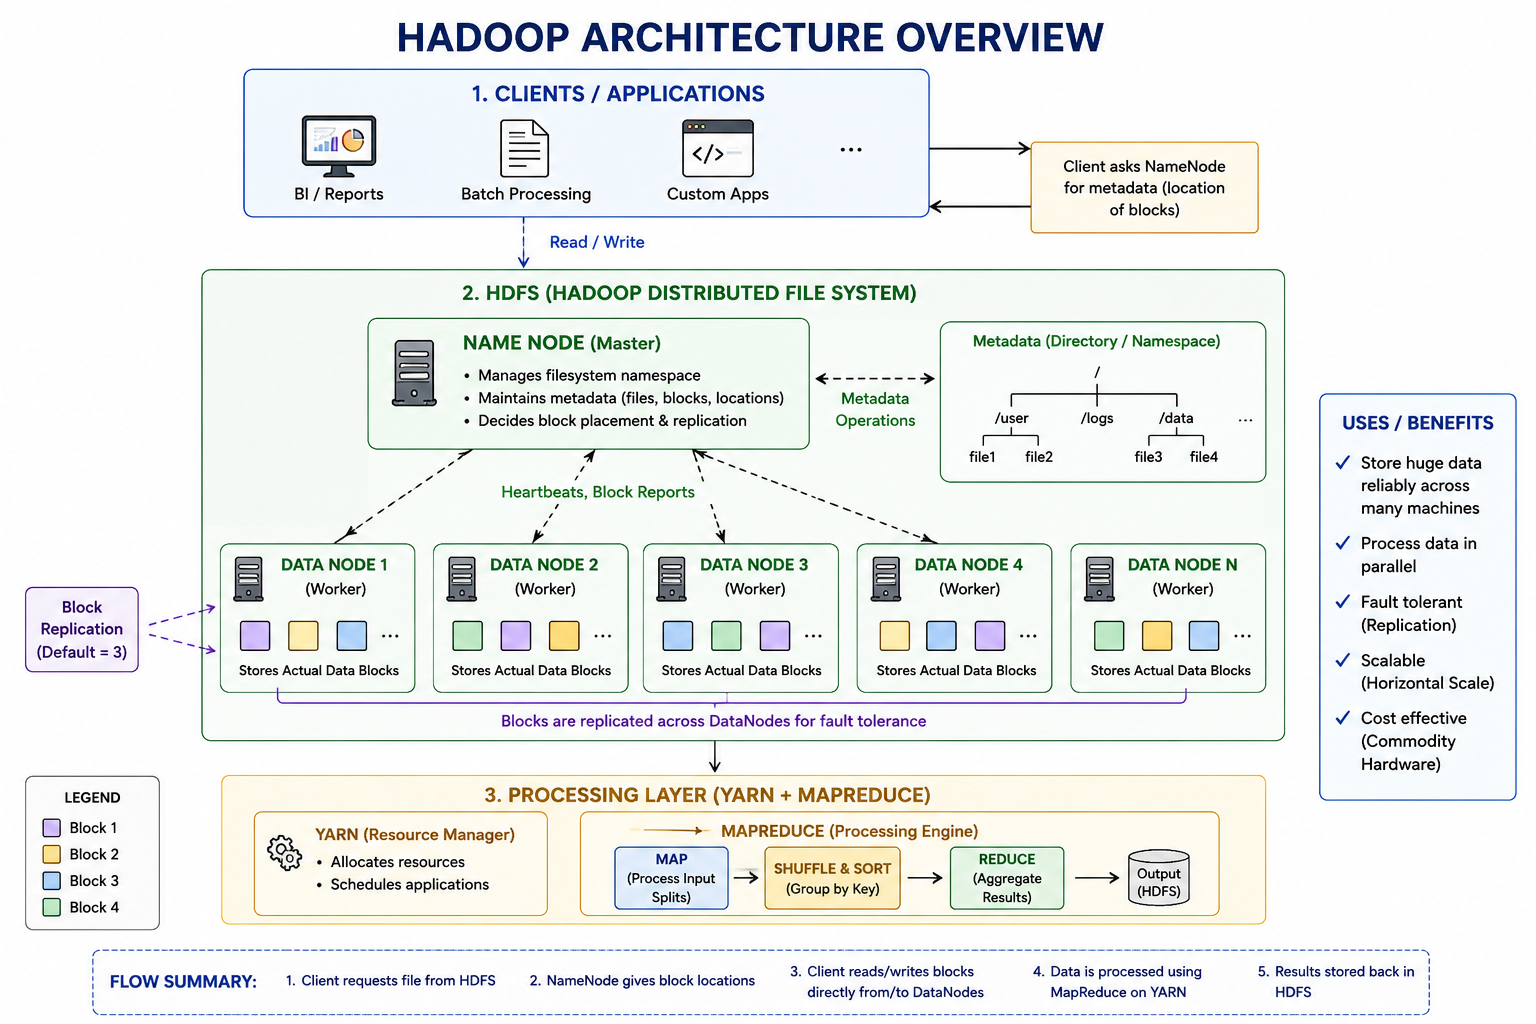

# 19. Student Mini Exercise

## Task

Modify the MapReduce logic to calculate:

```text
Number of completed orders by city
```

Expected output columns:

```text
city
completed_order_count
```


In [ ]:
# Step 1: Map phase
# Emit (city, 1) for completed orders

mapped_counts = []

# Write your code here

mapped_counts[:10]


[]

In [ ]:
# Step 2: Shuffle phase
# Group counts by city

shuffled_counts = defaultdict(list)

# Write your code here

dict(shuffled_counts)


{}

In [ ]:
# Step 3: Reduce phase
# Sum counts by city

order_counts = {}

# Write your code here

order_counts


{}

# 20. Interview Questions

## Q1. How does HDFS handle a DataNode failure?

HDFS uses replication and heartbeats.

DataNodes send heartbeat messages to the NameNode.

If a DataNode fails, the NameNode detects missing heartbeats, marks the node as failed, and uses other replicas to serve reads.

Then it schedules re-replication to restore the configured replication factor.

---

## Q2. What is the default block size in HDFS and why is it large?

A common HDFS block size is 128 MB.

It is large because HDFS is optimized for large sequential reads.

Large blocks reduce metadata overhead and improve throughput.

---

## Q3. Why was Hadoop MapReduce replaced by Apache Spark for most ETL tasks?

MapReduce frequently wrote intermediate data to disk.

Multi-step ETL jobs became slow because each stage read and wrote from HDFS.

Spark became popular because it supports in-memory processing, DAG execution, Spark SQL, and easier APIs.


# 21. Final Summary

In this notebook, we simulated the key parts of Hadoop:

```text
HDFS block splitting
NameNode metadata
DataNode storage
Replication factor
DataNode failure recovery
Map → Shuffle → Reduce
```

Main takeaway:

```text
HDFS solved distributed storage.
MapReduce solved distributed batch processing.
Spark improved performance by reducing repeated disk I/O.
```
